In [6]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebook" else Path.cwd().resolve()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT = Path(r"C:\Users\pong0\OneDrive\เอกสาร\Code\dynamic_port_opt")
#paths = default_paths(ROOT)

from dynamic_factor_copula import (
    backtest_dynamic_factor_copula,
    build_overlay_comparison,
    compare_apply_returns,
    compare_rebalanced_portfolio,
    compare_sp_exposure,
    compare_trend_exposure,
    compute_port_opt_style_metrics,
    curve_from_returns,
    default_paths,
    load_cached_market_data,
    load_overlay_compare_prices,
    compute_port_opt_style_metrics,
    lag_close_signal_to_next_session,
    curve_from_returns
)
paths = default_paths(ROOT)

In [7]:
results = backtest_dynamic_factor_copula(
    start_date="2012-01-01",
    end_date="2026-04-30",
    n_assets=30,
    n_clusters=4,
    lookback_days=726,
    rebalance_freq="ME",
    max_weight=0.08,
    point_in_time_liquid=True,
    universe_mode="sp500_pit",
    include_momentum_features=True,
    include_momentum_signal=True,
    momentum_signal_mode="mom_63",
    feature_flags={"resid_vol": False, "drawdown": False, "downside_beta": False},
    paths=paths,
)

static_curve = results["nav"]["Static Copula"]
print(static_curve.tail())

2026-04-24    11.848450
2026-04-27    11.901449
2026-04-28    11.849202
2026-04-29    12.010697
2026-04-30    12.224125
dtype: float64


<Axes: >

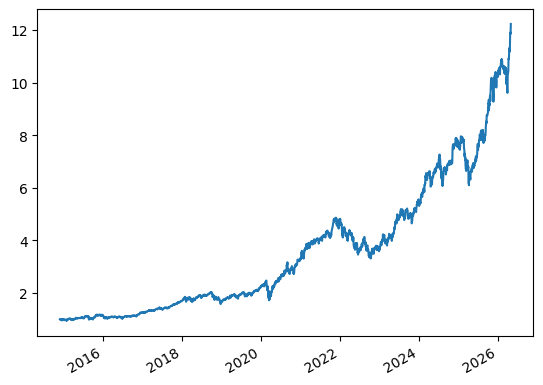

In [8]:
static_curve.plot()

In [9]:
metrics = compute_port_opt_style_metrics(static_curve, risk_free_rate=0.03)
print(metrics)

Total Return    11.224125
CAGR             0.245747
Annual Vol       0.220506
Sharpe           0.971907
Sortino          1.256446
Max Drawdown    -0.318598
Hit Rate         0.555052
dtype: float64


In [10]:
results = backtest_dynamic_factor_copula(
    start_date="2012-01-01",
    end_date="2026-04-30",
    n_assets=30,
    n_clusters=4,
    lookback_days=504,
    rebalance_freq="ME",
    max_weight=0.08,
    point_in_time_liquid=True,
    universe_mode="sp500_pit",
    include_momentum_features=True,
    include_momentum_signal=True,
    momentum_signal_mode="mom_63",
    feature_flags={"resid_vol": False, "drawdown": False, "downside_beta": False},
    paths=paths,
)

static_curve = results["nav"]["Static Copula"]
print(static_curve.tail())

2026-04-24    14.860200
2026-04-27    14.948479
2026-04-28    14.884270
2026-04-29    15.115727
2026-04-30    15.412507
dtype: float64


In [11]:
metrics = compute_port_opt_style_metrics(static_curve, risk_free_rate=0.03)
print(metrics)

Total Return    14.412507
CAGR             0.250805
Annual Vol       0.219453
Sharpe           0.993933
Sortino          1.283001
Max Drawdown    -0.301588
Hit Rate         0.559597
dtype: float64


In [12]:
cached = load_cached_market_data(paths)
spx = cached["benchmark"]["benchmark"].sort_index().ffill()
print(spx.tail())

Date
2026-04-27    715.169983
2026-04-28    711.690002
2026-04-29    711.580017
2026-04-30    718.659973
2026-05-01    720.650024
Name: benchmark, dtype: float64


In [91]:
import numpy as np
import pandas as pd

# benchmark = pd.Series ที่มี DatetimeIndex และค่าเป็นราคาปิด
spx.index = pd.to_datetime(spx.index)
spx = spx.sort_index().dropna()

# สร้าง DataFrame
signal_df = spx.rename("benchmark").to_frame()

# MA200
signal_df["ma200"] = signal_df["benchmark"].rolling(
    window=200,
    min_periods=200
).mean()

# Signal จากข้อมูล ณ วันปิดตลาด
# 1 = ราคาอยู่เหนือ MA200
# 0 = ราคาอยู่ต่ำกว่าหรือเท่ากับ MA200
signal_df["raw_signal"] = np.where(
    signal_df["benchmark"] > signal_df["ma200"],
    1,
    0
)

# ใช้ signal ในวันถัดไป เพื่อไม่ใช้ข้อมูลอนาคต
signal_df["signal"] = signal_df["raw_signal"].shift(1)

# จุดเปลี่ยน Signal
#  1 = เปลี่ยนจาก Below MA200 -> Above MA200
# -1 = เปลี่ยนจาก Above MA200 -> Below MA200
#  0 = ไม่มีการเปลี่ยนสถานะ
signal_df["signal_change"] = signal_df["signal"].diff().fillna(0)

# ตั้ง Exposure ตาม Rule:
# SPY > MA200 -> 70%
# SPY < MA200 -> 35%
signal_df["exposure"] = np.where(
    signal_df["signal"] == 1,
    1,
    0
)

# วันก่อน MA200 ครบ 200 วัน จะยังไม่มี signal ที่ใช้ได้
signal_df.loc[signal_df["ma200"].isna(), ["raw_signal", "signal", "exposure"]] = np.nan

signal_df = signal_df.dropna(subset=["ma200", "signal"])

# -----------------------------
# 2) แปลง port_growth เป็น Daily Return
# -----------------------------
port_df = static_curve.rename("port_growth").to_frame()

port_df["port_return"] = port_df["port_growth"].pct_change()

# -----------------------------
# 3) รวมกับ Exposure รายวัน
# -----------------------------
result_df = port_df.join(
    signal_df[["benchmark", "ma200", "signal", "exposure"]],
    how="inner"
)

result_df = result_df.dropna(subset=["port_return", "exposure"])

# -----------------------------
# 4) คำนวณ Return หลังปรับ Daily Exposure
# -----------------------------
# สมมติส่วนที่ไม่ได้ลงทุนถือเป็นเงินสด ผลตอบแทน = 0%
result_df["strategy_return"] = (
    result_df["port_return"] * result_df["exposure"]
)

# สร้าง Growth Curve ใหม่
result_df["strategy_growth"] = (
    1 + result_df["strategy_return"]
).cumprod()

# เปรียบเทียบกับพอร์ตเดิม โดย normalize จุดเริ่มต้น = 1
result_df["original_growth"] = (
    1 + result_df["port_return"]
).cumprod()

print(result_df.tail(20))

            port_growth  port_return   benchmark       ma200  signal  \
2026-04-02    12.940945     0.011010  655.830017  659.038452     0.0   
2026-04-06    13.067172     0.009754  658.929993  659.379312     0.0   
2026-04-07    13.103892     0.002810  659.219971  659.722068     0.0   
2026-04-08    13.514557     0.031339  676.010010  660.155710     0.0   
2026-04-09    13.709808     0.014447  679.909973  660.579749     1.0   
2026-04-10    13.703694    -0.000446  679.460022  660.968667     1.0   
2026-04-13    13.773117     0.005066  686.099976  661.389099     1.0   
2026-04-14    13.990877     0.015811  694.460022  661.827780     1.0   
2026-04-15    14.071950     0.005795  699.940002  662.278790     1.0   
2026-04-16    14.240349     0.011967  701.659973  662.723823     1.0   
2026-04-17    14.206905    -0.002349  710.140015  663.212248     1.0   
2026-04-20    14.113926    -0.006545  708.719971  663.679690     1.0   
2026-04-21    14.077925    -0.002551  704.080017  664.099688    

<Axes: >

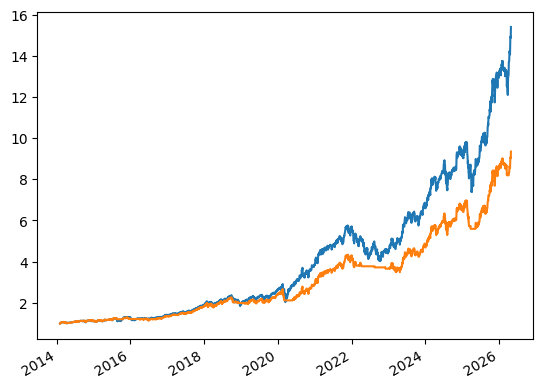

In [92]:
result_df['original_growth'].plot()
result_df['strategy_growth'].plot()

In [99]:
metrics = compute_port_opt_style_metrics(result_df['strategy_growth'], risk_free_rate=0.03)
print(metrics)

Total Return    8.572558
CAGR            0.203073
Annual Vol      0.168876
Sharpe          1.002538
Sortino         1.213294
Max Drawdown   -0.206515
Hit Rate        0.467511
dtype: float64


In [100]:
prices = load_overlay_compare_prices(
    paths,
    start_date="2016-01-01",
    end_date="2026-04-29",
    tickers=["GC=F", "BTC-USD"],
)

gold = prices["GC=F"].dropna()
btc = prices["BTC-USD"].dropna()

print(gold.tail())
print(btc.tail())

Date
2026-04-25    4722.299805
2026-04-26    4722.299805
2026-04-27    4675.399902
2026-04-28    4591.500000
2026-04-29    4545.200195
Name: GC=F, dtype: float64
Date
2026-04-25    77612.015625
2026-04-26    78657.539062
2026-04-27    77366.625000
2026-04-28    76350.671875
2026-04-29    75776.132812
Name: BTC-USD, dtype: float64


In [101]:
overlay_df = load_overlay_compare_prices(
    paths,
    start_date="2016-01-01",
    end_date="2026-04-29",
    tickers=["BTC-USD"],
)

In [102]:
def compare_trend_exposure(price: pd.Series, floor_exposure: float,ma_period=200) -> pd.Series:
    ma = price.rolling(ma_period).mean()
    signal_exposure = pd.Series(1.0, index=price.index, dtype=float)
    signal_exposure.loc[price < ma] = floor_exposure
    daily_exposure = lag_close_signal_to_next_session(signal_exposure)
    return daily_exposure

def build_btc_overlay_strategy(overlay_df: pd.DataFrame,ma_period) -> pd.DataFrame:
    """
    Expected columns in overlay_df:
    - 'BTC-USD' : BTC price series

    Returns a DataFrame with:
    - BTC Price
    - BTC Return
    - BTC Exposure
    - BTC Overlay Return
    - BTC Overlay Growth
    """
    df = overlay_df.copy()
    df = df.sort_index()

    btc_price = df["BTC-USD"].astype(float).ffill()
    btc_return = btc_price.pct_change(fill_method=None).fillna(0.0)

    # floor_exposure = 0.00 for BTC in this repo
    btc_exposure = compare_trend_exposure(btc_price, 0.00,ma_period)

    btc_overlay_return = btc_return.mul(btc_exposure.reindex(btc_return.index).fillna(1.0))
    btc_overlay_growth = curve_from_returns(btc_overlay_return)

    out = pd.DataFrame(
        {
            "BTC Price": btc_price,
            "BTC Return": btc_return,
            "BTC Exposure": btc_exposure,
            "BTC Overlay Return": btc_overlay_return,
            "BTC Overlay Growth": btc_overlay_growth,
        }
    )
    return out

<Axes: xlabel='Date'>

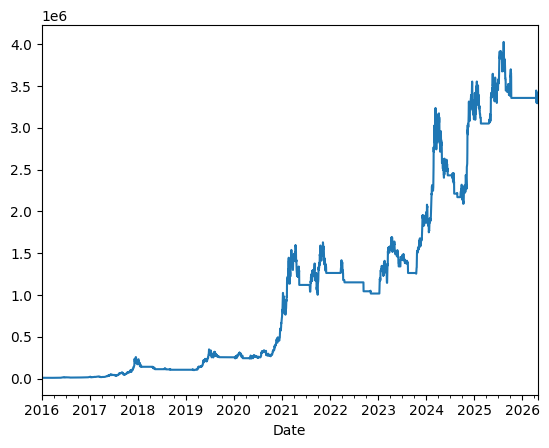

In [138]:
btc_strategy = build_btc_overlay_strategy(overlay_df,ma_period=100)
btc_strategy['BTC Overlay Growth'].plot()

In [139]:
sp_df=result_df.copy()

In [140]:
port_df=sp_df.join(gold)
port_df=port_df.join(btc_strategy).dropna()
port_df['GC=F']=port_df['GC=F']/port_df['GC=F'].iloc[0]
port_df['BTC Overlay Growth']=port_df['BTC Overlay Growth']/port_df['BTC Overlay Growth'].iloc[0]
port_df['strategy_growth']=port_df['strategy_growth']/port_df['strategy_growth'].iloc[0]

In [106]:
port_df

,port_growth,port_return,benchmark,ma200,signal,exposure,strategy_return,strategy_growth,original_growth,GC=F,BTC Price,BTC Return,BTC Exposure,BTC Overlay Return,BTC Overlay Growth
2016-01-04,1.250505,-0.023027,169.908142,172.437839,0.0,0.0,-0.000000,1.000000,1.250505,1.000000,433.091003,0.007163,1.0,0.007163,1.000000
2016-01-05,1.251933,0.001143,170.195526,172.413682,0.0,0.0,0.000000,1.000000,1.251933,1.003070,431.959991,-0.002611,1.0,-0.002611,0.997389
2016-01-06,1.240305,-0.009288,168.048615,172.380495,0.0,0.0,-0.000000,1.000000,1.240305,1.015626,429.105011,-0.006609,1.0,-0.006609,0.990796
2016-01-07,1.203969,-0.029296,164.016922,172.332058,0.0,0.0,-0.000000,1.000000,1.203969,1.030323,458.048004,0.067450,1.0,0.067450,1.057625
2016-01-08,1.188390,-0.012939,162.216553,172.287346,0.0,0.0,-0.000000,1.000000,1.188390,1.021114,453.230011,-0.010519,1.0,-0.010519,1.046501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-23,14.374363,0.003182,708.450012,665.045078,1.0,1.0,0.003182,7.246765,14.374363,4.376430,78268.953125,0.000842,1.0,0.000842,462.077839
2026-04-24,14.860200,0.033799,713.940002,665.520723,1.0,1.0,0.033799,7.491697,14.860200,4.392429,77455.312500,-0.010395,1.0,-0.010395,457.274334
2026-04-27,14.948479,0.005941,715.169983,665.993792,1.0,1.0,0.005941,7.536203,14.948479,4.348805,77366.625000,-0.016412,1.0,-0.016412,456.750748
2026-04-28,14.884270,-0.004295,711.690002,666.460367,1.0,1.0,-0.004295,7.503832,14.884270,4.270766,76350.671875,-0.013132,1.0,-0.013132,450.752847


In [107]:
compute_port_opt_style_metrics(port_df['strategy_growth'], risk_free_rate=0.03)

Total Return    6.620520
CAGR            0.218006
Annual Vol      0.175440
Sharpe          1.041969
Sortino         1.249957
Max Drawdown   -0.206515
Hit Rate        0.464919
dtype: float64

In [108]:
compute_port_opt_style_metrics(port_df['GC=F']*0.3+port_df['strategy_growth']*0.7, risk_free_rate=0.03)
#port_df['GC=F']*0.3+port_df['strategy_growth']*0.7

Total Return    5.602674
CAGR            0.201166
Annual Vol      0.141842
Sharpe          1.152738
Sortino         1.486787
Max Drawdown   -0.178301
Hit Rate        0.553200
dtype: float64

In [110]:
compute_port_opt_style_metrics(port_df['GC=F']*0.3+port_df['original_growth']*0.7, risk_free_rate=0.03)

Total Return    9.081496
CAGR            0.251561
Annual Vol      0.193831
Sharpe          1.101036
Sortino         1.425749
Max Drawdown   -0.274697
Hit Rate        0.556669
dtype: float64

In [141]:
compute_port_opt_style_metrics(port_df['GC=F']*0.275+port_df['strategy_growth']*0.7+port_df['BTC Overlay Growth']*0.025, risk_free_rate=0.03)

Total Return    13.763142
CAGR             0.298789
Annual Vol       0.219172
Sharpe           1.166047
Sortino          1.544785
Max Drawdown    -0.273189
Hit Rate         0.547417
dtype: float64

In [144]:
compute_port_opt_style_metrics(port_df['GC=F']*0.25+port_df['strategy_growth']*0.7+port_df['BTC Overlay Growth']*0.05, risk_free_rate=0.03)

Total Return    21.923609
CAGR             0.355492
Annual Vol       0.273713
Sharpe           1.138502
Sortino          1.496637
Max Drawdown    -0.311838
Hit Rate         0.543562
dtype: float64

In [145]:
compute_port_opt_style_metrics(port_df['GC=F']*0.3+port_df['strategy_growth']*0.7, risk_free_rate=0.03)

Total Return    5.602674
CAGR            0.201166
Annual Vol      0.141842
Sharpe          1.152738
Sortino         1.486787
Max Drawdown   -0.178301
Hit Rate        0.553200
dtype: float64

<Axes: >

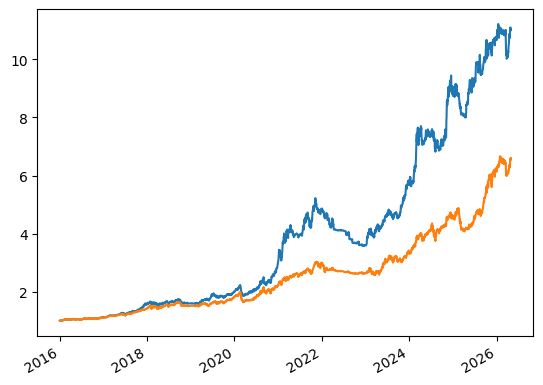

In [114]:
(port_df['GC=F']*0.29+port_df['strategy_growth']*0.7+port_df['BTC Overlay Growth']*0.01).plot()
(port_df['GC=F']*0.3+port_df['strategy_growth']*0.7).plot()

In [115]:
port_df['BTC Overlay Growth']*0.025

2016-01-04     0.025000
2016-01-05     0.024935
2016-01-06     0.024770
2016-01-07     0.026441
2016-01-08     0.026163
                ...    
2026-04-23    11.551946
2026-04-24    11.431858
2026-04-27    11.418769
2026-04-28    11.268821
2026-04-29    11.184023
Name: BTC Overlay Growth, Length: 2595, dtype: float64

In [116]:
signal_df

,benchmark,ma200,raw_signal,signal,signal_change,exposure
Date,,,,,,
2003-11-17,69.324394,63.189497,1.0,0.0,0.0,0.0
2003-11-18,68.604279,63.253691,1.0,1.0,1.0,1.0
2003-11-19,69.185646,63.322523,1.0,1.0,0.0,1.0
2003-11-20,68.564636,63.389556,1.0,1.0,0.0,1.0
2003-11-21,68.848740,63.461374,1.0,1.0,0.0,1.0
...,...,...,...,...,...,...
2026-04-27,715.169983,665.993792,1.0,1.0,0.0,1.0
2026-04-28,711.690002,666.460367,1.0,1.0,0.0,1.0
2026-04-29,711.580017,666.920493,1.0,1.0,0.0,1.0


In [117]:
sp_exposure=(1+signal_df['benchmark'].pct_change()*signal_df['exposure']).cumprod()

In [118]:
compute_port_opt_style_metrics(signal_df['benchmark'], risk_free_rate=0.03)

Total Return    9.395331
CAGR            0.110097
Annual Vol      0.186672
Sharpe          0.492437
Sortino         0.601897
Max Drawdown   -0.551895
Hit Rate        0.552231
dtype: float64

In [119]:
compute_port_opt_style_metrics(sp_exposure, risk_free_rate=0.03)

Total Return    4.919808
CAGR            0.082576
Annual Vol      0.114929
Sharpe          0.487229
Sortino         0.550258
Max Drawdown   -0.206768
Hit Rate        0.447140
dtype: float64

In [150]:
compute_port_opt_style_metrics(port_df['BTC Overlay Growth'], risk_free_rate=0.03)

Total Return    329.646406
CAGR              0.756528
Annual Vol        0.516864
Sharpe            1.287495
Sortino           1.506321
Max Drawdown     -0.600383
Hit Rate          0.328450
dtype: float64

In [146]:
asset_allo=port_df['GC=F']*0.275+sp_exposure*0.7+port_df['BTC Overlay Growth']*0.025

<Axes: >

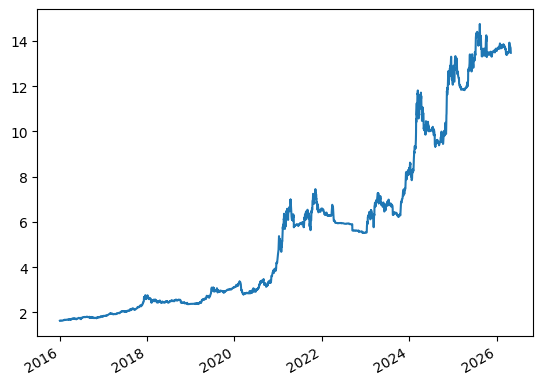

In [147]:
asset_allo.plot()

In [125]:
compute_port_opt_style_metrics(sp_exposure, risk_free_rate=0.03)

Total Return    4.919808
CAGR            0.082576
Annual Vol      0.114929
Sharpe          0.487229
Sortino         0.550258
Max Drawdown   -0.206768
Hit Rate        0.447140
dtype: float64

In [126]:
compute_port_opt_style_metrics(port_df['GC=F'], risk_free_rate=0.03)

Total Return    3.227700
CAGR            0.150273
Annual Vol      0.164986
Sharpe          0.750133
Sortino         0.967481
Max Drawdown   -0.208725
Hit Rate        0.538165
dtype: float64

In [49]:
compute_port_opt_style_metrics(port_df['BTC Overlay Growth'], risk_free_rate=0.03)

Total Return    446.360930
CAGR              0.808860
Annual Vol        0.493720
Sharpe            1.384187
Sortino           1.609606
Max Drawdown     -0.565625
Hit Rate          0.319969
dtype: float64

<Axes: >

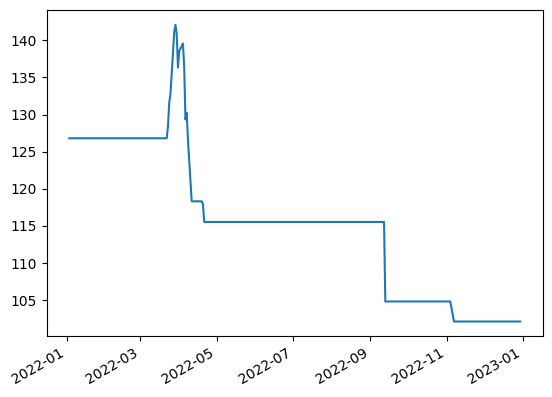

In [149]:
port_df[port_df.index.year==2022]['BTC Overlay Growth'].plot()

In [151]:
asset_allo=(port_df['GC=F']*0.25+sp_exposure*0.7+port_df['BTC Overlay Growth']*0.05).dropna()
compute_port_opt_style_metrics(asset_allo, risk_free_rate=0.03)

Total Return    12.241744
CAGR             0.285144
Annual Vol       0.250419
Sharpe           1.007166
Sortino          1.298688
Max Drawdown    -0.302171
Hit Rate         0.547417
dtype: float64

In [152]:
for i in range(2016,2025):
    print(i,compute_port_opt_style_metrics(asset_allo[asset_allo.index.year==i]))

2016 Total Return    0.126344
CAGR            0.126344
Annual Vol      0.074966
Sharpe          1.231103
Sortino         1.706317
Max Drawdown   -0.035706
Hit Rate        0.553785
dtype: float64
2017 Total Return    0.649741
CAGR            0.653035
Annual Vol      0.176559
Sharpe          2.777957
Sortino         4.365226
Max Drawdown   -0.104611
Hit Rate        0.604000
dtype: float64
2018 Total Return   -0.159647
CAGR           -0.160230
Annual Vol      0.136320
Sharpe         -1.436965
Sortino        -1.509577
Max Drawdown   -0.212226
Hit Rate        0.500000
dtype: float64
2019 Total Return    0.420652
CAGR            0.420652
Annual Vol      0.212493
Sharpe          1.625464
Sortino         1.836042
Max Drawdown   -0.117025
Hit Rate        0.585657
dtype: float64
2020 Total Return    0.709634
CAGR            0.706014
Annual Vol      0.251006
Sharpe          2.144062
Sortino         2.992372
Max Drawdown   -0.178629
Hit Rate        0.563492
dtype: float64
2021 Total Return    0.44

<Axes: >

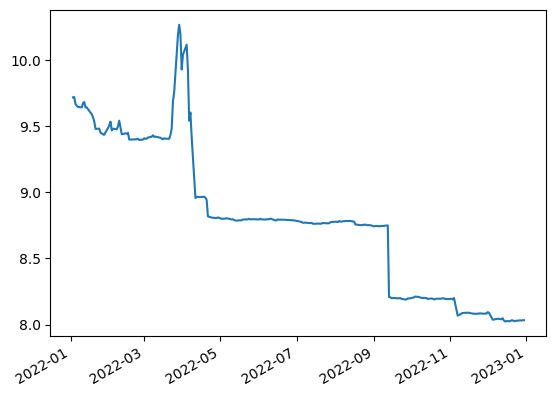

In [153]:
asset_allo[asset_allo.index.year==2022].plot()

In [86]:
signal_df

,benchmark,ma200,raw_signal,signal,signal_change,exposure
Date,,,,,,
2003-11-17,69.324394,63.189497,1.0,0.0,0.0,0.5
2003-11-18,68.604279,63.253691,1.0,1.0,1.0,1.0
2003-11-19,69.185646,63.322523,1.0,1.0,0.0,1.0
2003-11-20,68.564636,63.389556,1.0,1.0,0.0,1.0
2003-11-21,68.848740,63.461374,1.0,1.0,0.0,1.0
...,...,...,...,...,...,...
2026-04-27,715.169983,665.993792,1.0,1.0,0.0,1.0
2026-04-28,711.690002,666.460367,1.0,1.0,0.0,1.0
2026-04-29,711.580017,666.920493,1.0,1.0,0.0,1.0


<Axes: xlabel='Date'>

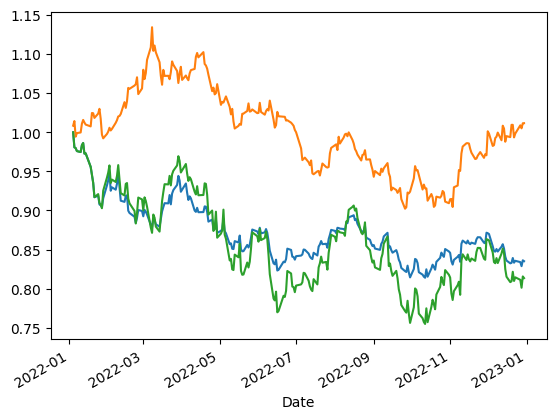

In [87]:
(1+sp_exposure[sp_exposure.index.year==2022].pct_change()).cumprod().plot()
(1+port_df[port_df['GC=F'].index.year==2022]['GC=F'].pct_change()).cumprod().plot()
(1+signal_df[signal_df.index.year==2022]['benchmark'].pct_change()).cumprod().plot()

<Axes: xlabel='Date'>

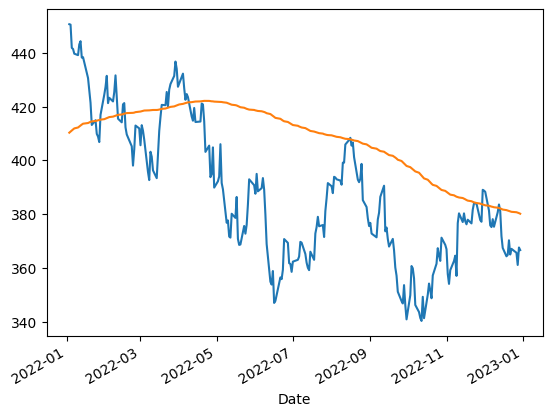

In [90]:
signal_df[signal_df.index.year==2022]['benchmark'].plot()
signal_df[signal_df.index.year==2022]['ma200'].plot()